# Layer05 q10 vs q394 MFA Comparison

This notebook compares two K=1000 component-sharded MFA runs trained on the same layer 5 Gemma-2B activation shards:

- q=10: `dalg-cache/pile_gemma2b_models/layer05_1000_10_component_sharded_mfa`
- q=394: `dalg-cache/pile_gemma2b_models/layer05_1000_394_component_sharded_mfa`

The notebook is safe to run before the long q394 assignment artifact exists: it reports missing inputs and skips dependent comparison sections. Once both assignment files are present, rerun all cells for the full comparison.

## 1. Setup and Artifact Validation

In [1]:
from __future__ import annotations

import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

try:
    import plotly.express as px
except Exception as exc:
    px = None
    print(f"Plotly unavailable: {exc}")


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / "pyproject.toml").exists() and (path / "src/dalg").exists():
            return path
    raise RuntimeError(f"Could not find repo root from {start}")

REPO = find_repo_root()
SHARD_DIR = REPO / "dalg-cache/pile_gemma2b_activations"
RUN_Q10 = REPO / "dalg-cache/pile_gemma2b_models/layer05_1000_10_component_sharded_mfa"
RUN_Q394 = REPO / "dalg-cache/pile_gemma2b_models/layer05_1000_394_component_sharded_mfa"
OUT_DIR = REPO / "output/experiments/layer05_q10_q394_comparison"
ASSIGN_Q10 = RUN_Q10 / "mfa_model_assignments.pt"
ASSIGN_Q394 = RUN_Q394 / "mfa_model_assignments.pt"
SUMMARY_PATH = OUT_DIR / "model_summaries.pt"

LAYER = 5
K = 1000
NEIGHBOR_KS = [5, 10, 25, 50]
RANK_THRESHOLDS = [0.90, 0.95, 0.99]
PAIR_SAMPLE = 20000
PAIR_SEED = 0

cfg10 = json.loads((RUN_Q10 / "config.json").read_text())
cfg394 = json.loads((RUN_Q394 / "config.json").read_text())
summary_cfg = pd.DataFrame([
    {"model": "q10", **{k: cfg10.get(k) for k in ["K", "rank", "layer", "d_model", "window", "drop_prefix", "training_mode", "world_size"]}},
    {"model": "q394", **{k: cfg394.get(k) for k in ["K", "rank", "layer", "d_model", "window", "drop_prefix", "training_mode", "world_size"]}},
])
display(summary_cfg)

assert cfg10["K"] == cfg394["K"] == K
assert cfg10["layer"] == cfg394["layer"] == LAYER
assert cfg10["d_model"] == cfg394["d_model"]

artifact_status = pd.DataFrame([
    {"artifact": "q10 assignments", "path": str(ASSIGN_Q10.relative_to(REPO)), "exists": ASSIGN_Q10.exists(), "size_gb": ASSIGN_Q10.stat().st_size / 1e9 if ASSIGN_Q10.exists() else 0.0},
    {"artifact": "q394 assignments", "path": str(ASSIGN_Q394.relative_to(REPO)), "exists": ASSIGN_Q394.exists(), "size_gb": ASSIGN_Q394.stat().st_size / 1e9 if ASSIGN_Q394.exists() else 0.0},
])
display(artifact_status)
HAVE_BOTH_ASSIGNMENTS = bool(ASSIGN_Q10.exists() and ASSIGN_Q394.exists())
if not HAVE_BOTH_ASSIGNMENTS:
    display(Markdown("**Pending input:** full comparison sections are skipped until both assignment files exist. Run q394 assignments to create `output/experiments/layer05_q10_q394_comparison/q394_assignments.pt`."))

,model,K,rank,layer,d_model,window,drop_prefix,training_mode,world_size
0,q10,1000,10,5,2048,256,32,component_shard,2
1,q394,1000,394,5,2048,256,32,component_shard,2


,artifact,path,exists,size_gb
0,q10 assignments,dalg-cache/pile_gemma2b_models/layer05_1000_10...,True,0.884278
1,q394 assignments,dalg-cache/pile_gemma2b_models/layer05_1000_39...,True,0.884278


## 1.1 Model NLL

In [2]:
for model_name, run_dir in [("q10", RUN_Q10), ("q394", RUN_Q394)]:
    checkpoint = torch.load(
        run_dir / "checkpoint_rank0000.pt",
        map_location="cpu",
        mmap=True,
        weights_only=True,
    )
    print(f"{model_name} NLL: {float(checkpoint['best_metric']):.6f}")
    del checkpoint

q10 NLL: 1726.062406


q394 NLL: 1075.520253


## 1.2 Empty Clusters

In [3]:
empty_cluster_counts = {}
for model_name, assignment_path in [("q10", ASSIGN_Q10), ("q394", ASSIGN_Q394)]:
    if not assignment_path.exists():
        print(f"{model_name} empty clusters: unavailable (missing assignment artifact)")
        continue

    assignment_bundle = torch.load(
        assignment_path, map_location="cpu", mmap=True, weights_only=True
    )
    cluster_sizes = assignment_bundle["cluster_sizes"].reshape(-1)
    assert cluster_sizes.numel() == int(assignment_bundle["K"]) == K
    assert int(cluster_sizes.sum()) == assignment_bundle["assignments"].numel()
    empty_cluster_counts[model_name] = int((cluster_sizes == 0).sum())
    print(f"{model_name} empty clusters: {empty_cluster_counts[model_name]}")
    del assignment_bundle, cluster_sizes

q10 empty clusters: 0
q394 empty clusters: 378


## 2. Assignment Agreement

Both assignment bundles label the same activation stream with `K=1000` clusters. We treat q10 as the reference partition and compute all scores exactly from the contingency matrix `C[i, j] = #tokens assigned to q10 cluster i and q394 cluster j`:

- **ARI** measures pairwise co-assignment agreement, adjusted for chance.
- **NMI** uses geometric-mean entropy normalization.
- **Completeness** asks whether all tokens from each q10 cluster stay together in one q394 cluster.
- **Homogeneity** asks whether each q394 cluster contains tokens from only one q10 cluster.

The first table compares the partitions independently of their numeric cluster ids. The second table applies the Hungarian one-to-one mapping that maximizes token agreement and contrasts the raw and relabeled comparisons. ARI, NMI, completeness, and homogeneity are invariant to this relabeling; exact label agreement is not.

In [4]:
def load_assignment_bundle(path: Path) -> dict:
    bundle = torch.load(path, map_location="cpu", mmap=True, weights_only=True)
    bundle["assignments"] = bundle["assignments"].reshape(-1).to(torch.long)
    bundle["cluster_sizes"] = bundle["cluster_sizes"].reshape(-1).to(torch.long)
    return bundle


def build_contingency(
    labels_x: torch.Tensor,
    labels_y: torch.Tensor,
    n_clusters: int,
    *,
    chunk_size: int = 5_000_000,
) -> np.ndarray:
    """Count paired labels in bounded-memory chunks."""
    if labels_x.numel() != labels_y.numel():
        raise ValueError(f"Assignment lengths differ: {labels_x.numel():,} != {labels_y.numel():,}")

    counts = torch.zeros(n_clusters * n_clusters, dtype=torch.long)
    for start in range(0, labels_x.numel(), chunk_size):
        stop = min(start + chunk_size, labels_x.numel())
        pair_ids = labels_x[start:stop].mul(n_clusters)
        pair_ids.add_(labels_y[start:stop])
        counts.add_(torch.bincount(pair_ids, minlength=n_clusters * n_clusters))
    return counts.reshape(n_clusters, n_clusters).numpy()


def partition_metrics_from_contingency(contingency: np.ndarray) -> dict[str, float]:
    """ARI, geometric NMI, completeness, and homogeneity from count data."""
    n = int(contingency.sum())
    row_counts = contingency.sum(axis=1)
    col_counts = contingency.sum(axis=0)

    def entropy(counts: np.ndarray) -> float:
        positive = counts[counts > 0].astype(np.float64)
        probabilities = positive / positive.sum()
        return float(-(probabilities * np.log(probabilities)).sum())

    h_q10 = entropy(row_counts)
    h_q394 = entropy(col_counts)
    nz_q10, nz_q394 = np.nonzero(contingency)
    joint_counts = contingency[nz_q10, nz_q394].astype(np.float64)
    p_joint = joint_counts / n
    p_q10 = row_counts[nz_q10].astype(np.float64) / n
    p_q394 = col_counts[nz_q394].astype(np.float64) / n
    mutual_information = float((p_joint * np.log(p_joint / (p_q10 * p_q394))).sum())

    if h_q10 == 0.0 and h_q394 == 0.0:
        nmi = 1.0
    elif h_q10 == 0.0 or h_q394 == 0.0:
        nmi = 0.0
    else:
        nmi = mutual_information / math.sqrt(h_q10 * h_q394)
    homogeneity = mutual_information / h_q10 if h_q10 > 0.0 else 1.0
    completeness = mutual_information / h_q394 if h_q394 > 0.0 else 1.0

    def pair_count(counts: np.ndarray) -> float:
        values = counts.astype(np.float64, copy=False)
        return float((values * (values - 1.0) / 2.0).sum())

    joint_pairs = pair_count(contingency)
    q10_pairs = pair_count(row_counts)
    q394_pairs = pair_count(col_counts)
    total_pairs = n * (n - 1) / 2
    expected_pairs = q10_pairs * q394_pairs / total_pairs if total_pairs else 0.0
    max_pairs = 0.5 * (q10_pairs + q394_pairs)
    denominator = max_pairs - expected_pairs
    ari = (joint_pairs - expected_pairs) / denominator if denominator else 1.0

    return {
        "adjusted_rand_index": ari,
        "normalized_mutual_information": nmi,
        "cluster_completeness": completeness,
        "cluster_homogeneity": homogeneity,
    }


In [5]:
if not HAVE_BOTH_ASSIGNMENTS:
    display(Markdown("**Skipped:** both assignment artifacts are required."))
else:
    assign10_obj = load_assignment_bundle(ASSIGN_Q10)
    assign394_obj = load_assignment_bundle(ASSIGN_Q394)
    a10 = assign10_obj["assignments"]
    a394 = assign394_obj["assignments"]

    assert int(assign10_obj["K"]) == int(assign394_obj["K"]) == K
    assert assign10_obj.get("subset_spec") == assign394_obj.get("subset_spec")
    assert a10.numel() == a394.numel()
    N = a10.numel()
    print(f"Loaded {N:,} aligned token assignments per model")

    contingency = build_contingency(a10, a394, K)
    row_counts = contingency.sum(axis=1)
    col_counts = contingency.sum(axis=0)
    np.testing.assert_array_equal(row_counts, assign10_obj["cluster_sizes"].numpy())
    np.testing.assert_array_equal(col_counts, assign394_obj["cluster_sizes"].numpy())

    raw_metrics = partition_metrics_from_contingency(contingency)
    assignment_metrics = pd.DataFrame(
        [
            {"metric": "Adjusted Rand index (ARI)", "value": raw_metrics["adjusted_rand_index"]},
            {"metric": "Normalized mutual information (geometric NMI)", "value": raw_metrics["normalized_mutual_information"]},
            {"metric": "Cluster completeness (q10 reference)", "value": raw_metrics["cluster_completeness"]},
            {"metric": "Cluster homogeneity (q10 reference)", "value": raw_metrics["cluster_homogeneity"]},
        ]
    )
    display(assignment_metrics.style.format({"value": "{:.6f}"}))

    del a10, a394, assign10_obj, assign394_obj


Loaded 73,687,936 aligned token assignments per model


,metric,value
0,Adjusted Rand index (ARI),0.418346
1,Normalized mutual information (geometric NMI),0.760815
2,Cluster completeness (q10 reference),0.793008
3,Cluster homogeneity (q10 reference),0.729929


In [6]:
if HAVE_BOTH_ASSIGNMENTS:
    row_ind, col_ind = linear_sum_assignment(-contingency)
    match_q10_to_q394 = np.full(K, -1, dtype=np.int64)
    match_q10_to_q394[row_ind] = col_ind
    match_q394_to_q10 = np.full(K, -1, dtype=np.int64)
    match_q394_to_q10[col_ind] = row_ind

    matched_contingency = contingency[:, match_q10_to_q394]
    matched_metrics = partition_metrics_from_contingency(matched_contingency)
    invariant_keys = list(raw_metrics)
    assert np.allclose(
        [raw_metrics[key] for key in invariant_keys],
        [matched_metrics[key] for key in invariant_keys],
        rtol=1e-12,
        atol=1e-12,
    )

    raw_exact_agreement = float(np.trace(contingency) / N)
    matched_count = int(np.trace(matched_contingency))
    matched_agreement = matched_count / N
    hungarian_comparison = pd.DataFrame(
        [
            {"comparison": "Raw numeric cluster ids", "exact_label_agreement": raw_exact_agreement, **raw_metrics},
            {"comparison": "After Hungarian relabeling", "exact_label_agreement": matched_agreement, **matched_metrics},
        ]
    ).set_index("comparison")
    display(hungarian_comparison.style.format("{:.6f}"))
    print(f"Hungarian matching aligns {matched_count:,} / {N:,} token assignments.")

,exact_label_agreement,adjusted_rand_index,normalized_mutual_information,cluster_completeness,cluster_homogeneity
comparison,,,,,
Raw numeric cluster ids,0.446164,0.418346,0.760815,0.793008,0.729929
After Hungarian relabeling,0.499824,0.418346,0.760815,0.793008,0.729929


Hungarian matching aligns 36,830,985 / 73,687,936 token assignments.


## 3. Where the Empty q394 Component Lineages Went

The two runs use exactly the same ordered initialization centroids. Therefore, q10 cluster `j` is the direct lineage counterpart of q394 component `j`. For every empty q394 component, we take the points assigned to its same-ID q10 cluster and use the contingency row to measure where those points are assigned by q394. This is a many-to-one flow analysis: it does not force an empty component to match an arbitrary q10 cluster.

In [7]:
if HAVE_BOTH_ASSIGNMENTS:
    def load_centroid_tensor(path: Path) -> torch.Tensor:
        obj = torch.load(path, map_location="cpu", weights_only=True)
        if isinstance(obj, dict):
            for key in ("centroids", "mu", "means"):
                if key in obj:
                    return obj[key]
            raise KeyError(f"No centroid tensor found in {path}")
        return obj

    init10 = load_centroid_tensor(RUN_Q10 / "centroids.pt")
    init394 = load_centroid_tensor(RUN_Q394 / "centroids.pt")
    assert torch.equal(init10, init394), "The lineage analysis requires identical ordered centroids"
    del init10, init394

    empty_q394_ids = np.flatnonzero(col_counts == 0)
    assert empty_q394_ids.size == empty_cluster_counts["q394"] == 378
    assert np.all(row_counts[empty_q394_ids] > 0)

    lineage_counts = contingency[empty_q394_ids]
    lineage_sizes = row_counts[empty_q394_ids]
    lineage_fractions = lineage_counts / lineage_sizes[:, None]
    dominant_positions = lineage_counts.argmax(axis=1)
    dominant_tokens = lineage_counts[np.arange(empty_q394_ids.size), dominant_positions]

    log_fractions = np.zeros_like(lineage_fractions, dtype=np.float64)
    np.log(lineage_fractions, out=log_fractions, where=lineage_fractions > 0)
    flow_entropy = -(lineage_fractions * log_fractions).sum(axis=1)
    top3_fraction = np.partition(lineage_fractions, K - 3, axis=1)[:, -3:].sum(axis=1)
    top5_fraction = np.partition(lineage_fractions, K - 5, axis=1)[:, -5:].sum(axis=1)

    empty_lineage_flows = pd.DataFrame({
        "component_id": empty_q394_ids,
        "q10_size": lineage_sizes,
        "dominant_q394_destination": dominant_positions,
        "dominant_tokens": dominant_tokens,
        "dominant_fraction_of_q10": dominant_tokens / lineage_sizes,
        "dominant_fraction_of_q394": dominant_tokens / col_counts[dominant_positions],
        "top3_fraction_of_q10": top3_fraction,
        "top5_fraction_of_q10": top5_fraction,
        "nonzero_destinations": (lineage_counts > 0).sum(axis=1),
        "destinations_at_least_1pct": (lineage_fractions >= 0.01).sum(axis=1),
        "effective_destinations": np.exp(flow_entropy),
    }).sort_values("dominant_fraction_of_q10", ascending=False, ignore_index=True)

    lineage_flow_summary = pd.DataFrame([
        {"metric": "empty q394 lineages", "value": empty_q394_ids.size},
        {"metric": "tokens in their q10 counterparts", "value": int(lineage_sizes.sum())},
        {"metric": "fraction of all tokens", "value": float(lineage_sizes.sum() / N)},
        {"metric": "median dominant-destination fraction", "value": float(empty_lineage_flows["dominant_fraction_of_q10"].median())},
        {"metric": "median effective destinations", "value": float(empty_lineage_flows["effective_destinations"].median())},
        {"metric": "mean destinations receiving at least one token", "value": float(empty_lineage_flows["nonzero_destinations"].mean())},
    ])
    display(lineage_flow_summary)
    display(Markdown("**Most concentrated lineage flows**"))
    display(empty_lineage_flows.head(20))
    display(Markdown("**Most fragmented lineage flows**"))
    display(empty_lineage_flows.tail(20).sort_values("dominant_fraction_of_q10"))


,metric,value
0,empty q394 lineages,3.780000e+02
1,tokens in their q10 counterparts,2.308655e+07
2,fraction of all tokens,3.133016e-01
3,median dominant-destination fraction,3.397238e-01
4,median effective destinations,9.296070e+00
5,mean destinations receiving at least one token,1.229709e+02


**Most concentrated lineage flows**

,component_id,q10_size,dominant_q394_destination,dominant_tokens,dominant_fraction_of_q10,dominant_fraction_of_q394,top3_fraction_of_q10,top5_fraction_of_q10,nonzero_destinations,destinations_at_least_1pct,effective_destinations
0,596,124960,477,123436,0.987804,0.354161,0.997175,0.998512,24,1,1.087472
1,82,71220,3,70135,0.984766,0.329569,0.997557,0.999031,23,2,1.101155
2,440,141692,477,138206,0.975397,0.396539,0.986788,0.990663,30,1,1.185425
3,487,110114,839,106798,0.969886,0.191560,0.986659,0.996068,19,1,1.207656
4,474,126356,500,120925,0.957018,0.324623,0.984670,0.992023,26,2,1.288232
5,114,67233,307,63174,0.939628,0.238179,0.984517,0.988384,47,2,1.374820
6,422,161407,833,151176,0.936614,0.206692,0.991822,0.995093,33,2,1.339813
7,25,64470,798,59571,0.924011,0.210402,0.949155,0.963937,72,3,1.627998
8,26,52850,649,48181,0.911656,0.163725,0.975648,0.984030,50,3,1.589431
9,497,152269,833,138351,0.908596,0.189158,0.948263,0.962757,178,3,1.750607


**Most fragmented lineage flows**

,component_id,q10_size,dominant_q394_destination,dominant_tokens,dominant_fraction_of_q10,dominant_fraction_of_q394,top3_fraction_of_q10,top5_fraction_of_q10,nonzero_destinations,destinations_at_least_1pct,effective_destinations
377,670,17383,500,1816,0.104470,0.004875,0.289191,0.412414,74,18,19.820901
376,385,36967,95,3962,0.107177,0.008444,0.296778,0.480537,107,14,17.616546
375,66,29217,452,3425,0.117226,0.010146,0.304549,0.459698,216,14,28.616853
374,858,28709,332,3671,0.127869,0.048936,0.325682,0.457418,222,19,35.429502
373,358,32547,269,4534,0.139306,0.028756,0.334009,0.472302,339,14,41.219392
372,194,56574,143,8294,0.146604,0.104016,0.374006,0.555520,104,14,16.174826
371,566,79395,614,11643,0.146647,0.067887,0.416097,0.597645,117,14,13.884901
370,667,66058,836,9720,0.147143,0.021861,0.362651,0.520679,149,15,18.735268
369,610,198648,421,29512,0.148564,0.111625,0.313796,0.375695,360,17,69.214253
368,437,11390,45,1716,0.150658,0.018534,0.435294,0.583319,97,17,20.019574


### 3.1 q394 Clusters That Absorbed the Empty Lineages

This reverses the view: for each occupied q394 destination, measure how many tokens and distinct empty-component lineages it absorbed. `empty_lineage_flows` retains all 378 source-level rows; `destination_absorption` retains every destination receiving any of their points.

In [8]:
if HAVE_BOTH_ASSIGNMENTS:
    absorbed_tokens = lineage_counts.sum(axis=0)
    largest_source_position = lineage_counts.argmax(axis=0)
    largest_source_tokens = lineage_counts[largest_source_position, np.arange(K)]
    destination_absorption = pd.DataFrame({
        "q394_cluster": np.arange(K),
        "q394_size": col_counts,
        "tokens_from_empty_lineages": absorbed_tokens,
        "fraction_of_q394_from_empty_lineages": np.divide(
            absorbed_tokens, col_counts,
            out=np.zeros(K, dtype=np.float64), where=col_counts > 0,
        ),
        "contributing_empty_lineages": (lineage_counts > 0).sum(axis=0),
        "significant_empty_lineages": (lineage_fractions >= 0.01).sum(axis=0),
        "largest_empty_lineage_source": empty_q394_ids[largest_source_position],
        "largest_source_tokens": largest_source_tokens,
        "largest_source_fraction_of_q394": np.divide(
            largest_source_tokens, col_counts,
            out=np.zeros(K, dtype=np.float64), where=col_counts > 0,
        ),
    })
    destination_absorption = (
        destination_absorption[destination_absorption["tokens_from_empty_lineages"] > 0]
        .sort_values("tokens_from_empty_lineages", ascending=False, ignore_index=True)
    )
    display(destination_absorption.head(30))


,q394_cluster,q394_size,tokens_from_empty_lineages,fraction_of_q394_from_empty_lineages,contributing_empty_lineages,significant_empty_lineages,largest_empty_lineage_source,largest_source_tokens,largest_source_fraction_of_q394
0,833,731406,721007,0.985782,268,37,422,151176,0.206692
1,839,557516,528641,0.948208,21,11,605,136810,0.245392
2,475,692929,470830,0.679478,320,30,42,89258,0.128813
3,821,468118,402264,0.859322,292,67,599,93817,0.200413
4,870,498438,396571,0.795628,272,48,701,69177,0.138788
5,95,469197,386757,0.824296,183,59,783,28003,0.059683
6,836,444621,386404,0.869064,281,60,541,111591,0.250980
7,604,487119,365813,0.750973,242,63,434,58651,0.120404
8,500,372509,362685,0.973627,41,15,474,120925,0.324623
9,847,407329,357692,0.878140,339,43,976,62510,0.153463


### 3.2 Partial-Hungarian Robustness Check

A rectangular Hungarian match pairs the 622 occupied q394 clusters with 622 distinct q10 clusters and leaves 378 q10 clusters unmatched. Those unmatched clusters describe partition-level redundancy, not one-to-one counterparts of particular empty components. We compare their IDs with the lineage-defined set above.

In [9]:
if HAVE_BOTH_ASSIGNMENTS:
    occupied_q394_ids = np.flatnonzero(col_counts > 0)
    matched_q10_ids, matched_occupied_positions = linear_sum_assignment(
        -contingency[:, occupied_q394_ids]
    )
    matched_q394_ids = occupied_q394_ids[matched_occupied_positions]
    unmatched_q10_ids = np.setdiff1d(np.arange(K), matched_q10_ids)
    partial_matched_count = int(contingency[matched_q10_ids, matched_q394_ids].sum())

    assert occupied_q394_ids.size == 622
    assert unmatched_q10_ids.size == empty_q394_ids.size == 378
    assert partial_matched_count == matched_count

    common_ids = np.intersect1d(empty_q394_ids, unmatched_q10_ids)
    union_ids = np.union1d(empty_q394_ids, unmatched_q10_ids)
    matching_set_comparison = pd.DataFrame([
        {"metric": "lineage-defined q10 clusters", "value": empty_q394_ids.size},
        {"metric": "partial-Hungarian unmatched q10 clusters", "value": unmatched_q10_ids.size},
        {"metric": "intersection", "value": common_ids.size},
        {"metric": "lineage set recovered by Hungarian", "value": common_ids.size / empty_q394_ids.size},
        {"metric": "set Jaccard", "value": common_ids.size / union_ids.size},
    ])
    display(matching_set_comparison)

    differing_cluster_ids = np.setxor1d(empty_q394_ids, unmatched_q10_ids)
    matching_set_differences = pd.DataFrame({
        "q10_cluster": differing_cluster_ids,
        "lineage_counterpart_of_empty_q394": np.isin(differing_cluster_ids, empty_q394_ids),
        "partial_hungarian_unmatched": np.isin(differing_cluster_ids, unmatched_q10_ids),
    })
    display(Markdown("**Clusters on which the two definitions disagree**"))
    display(matching_set_differences)


,metric,value
0,lineage-defined q10 clusters,378.000000
1,partial-Hungarian unmatched q10 clusters,378.000000
2,intersection,291.000000
3,lineage set recovered by Hungarian,0.769841
4,set Jaccard,0.625806


**Clusters on which the two definitions disagree**

,q10_cluster,lineage_counterpart_of_empty_q394,partial_hungarian_unmatched
0,0,False,True
1,7,False,True
2,12,True,False
3,15,True,False
4,16,True,False
...,...,...,...
169,969,True,False
170,970,False,True
171,976,True,False
172,991,False,True


## 4. Likelihood Geometry of Matched Components

This cell takes the 32 occupied Hungarian pairs with the most shared tokens. For each pair it samples 128 actual activations from the shared assignment core and decomposes the conditional Gaussian gain `NLL(q10 component) - NLL(q394 component)` into `0.5 * Δlog|C|` and `0.5 * ΔMahalanobis`. This excludes mixture-weight and mixture-logsumexp terms, so the decomposition isolates covariance fit rather than claiming to reproduce the global validation-NLL difference. For the same pairs it computes the exact full eigenspectra of the fitted Gaussian covariance `C = W Wᵀ + Ψ`; no empirical PCA spectra are used.

,q10_cluster,q394_cluster,shared_tokens,sampled_tokens,logdet_gain,mahalanobis_gain,conditional_nll_gain
0,91,91,491286,128,913.608641,-54.625994,858.982648
1,383,383,409245,128,868.534922,-73.086036,795.448886
2,266,266,332784,128,893.930431,-101.674799,792.255632
3,656,656,318419,128,905.456500,-1.119706,904.336794
4,988,988,314948,128,775.418592,-38.470627,736.947966
5,655,655,294056,128,759.765940,-41.700804,718.065135
6,400,400,272604,128,868.525079,-58.333998,810.191081
7,224,224,250926,128,867.090112,-11.749673,855.340439
8,832,832,249538,128,911.303676,-1.336521,909.967155
9,416,416,248981,128,788.710667,1.569219,790.279886


,term,mean,median
0,logdet_gain,806.008444,786.109955
1,mahalanobis_gain,-6.121766,-13.228546
2,conditional_nll_gain,799.886678,793.852259


,band,median_abs_log_eigenvalue_gap,median_logdet_gain_contribution
0,ranks 1-30,0.253917,-2.935590
1,ranks 31-400,1.197540,205.134323
2,ranks 401-2048,0.776200,591.067261


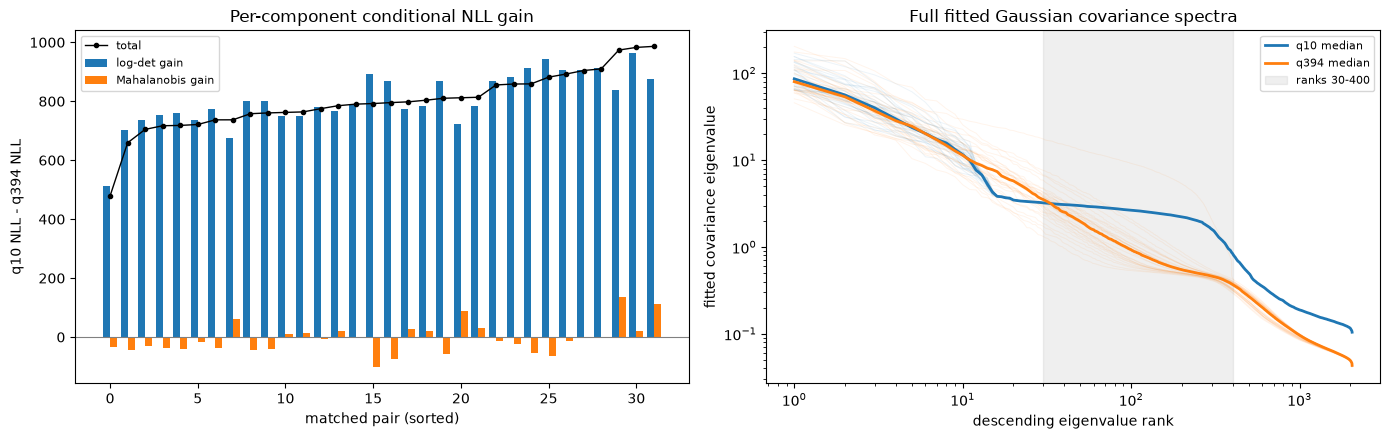

In [10]:
if HAVE_BOTH_ASSIGNMENTS:
    import matplotlib.pyplot as plt

    SPECTRUM_PAIR_COUNT = 32
    NLL_SAMPLES_PER_PAIR = 128
    CANDIDATE_SAMPLE_SIZE = 1_000_000
    GEOMETRY_SEED = 0

    def open_component_shards(run_dir: Path) -> dict:
        manifest = json.loads((run_dir / "mfa_model_shards.json").read_text())
        shards = []
        shared_psi = None
        for filename in manifest["shards"]:
            obj = torch.load(
                run_dir / filename, map_location="cpu", mmap=True, weights_only=True
            )
            state, meta = obj["state_dict"], obj["meta"]
            psi = torch.nn.functional.softplus(state["psi_rho"].float()) + float(meta["eps_floor"])
            if shared_psi is None:
                shared_psi = psi.clone()
            else:
                assert torch.equal(shared_psi, psi)
            shards.append({"state": state, "meta": meta})
        return {"shards": shards, "psi": shared_psi, "q": int(manifest["rank"])}

    def component_parameters(reader: dict, component_id: int) -> tuple[torch.Tensor, torch.Tensor]:
        for shard in reader["shards"]:
            meta = shard["meta"]
            if int(meta["component_start"]) <= component_id < int(meta["component_end"]):
                local_id = component_id - int(meta["component_start"])
                state = shard["state"]
                mu = state["mu"][local_id].float()
                direction = state["dir_raw"][local_id].float()
                direction = direction / direction.norm(dim=0, keepdim=True).clamp_min(float(meta["eps_floor"]))
                scale = torch.nn.functional.softplus(state["scale_rho"][local_id].float())
                return mu, direction * scale[None, :]
        raise IndexError(component_id)

    def fitted_covariance_spectrum(W: torch.Tensor, psi: torch.Tensor) -> torch.Tensor:
        covariance = W @ W.T
        covariance.diagonal().add_(psi)
        eigenvalues = torch.linalg.eigvalsh(covariance).flip(0).clamp_min(1e-12)
        del covariance
        return eigenvalues

    def mean_mahalanobis(
        x: torch.Tensor, mu: torch.Tensor, W: torch.Tensor, psi: torch.Tensor
    ) -> float:
        delta = x.double() - mu.double()[None, :]
        W64, psi64 = W.double(), psi.double()
        scaled_W = W64 / psi64[:, None]
        inner = torch.eye(W.shape[1], dtype=torch.float64) + W64.T @ scaled_W
        chol = torch.linalg.cholesky(inner)
        rhs = delta @ scaled_W
        projected = torch.linalg.solve_triangular(chol, rhs.T, upper=False).T
        quadratic = (delta.square() / psi64[None, :]).sum(dim=1) - projected.square().sum(dim=1)
        return float(quadratic.mean())

    pair_shared_counts = contingency[matched_q10_ids, matched_q394_ids]
    selected_positions = np.argsort(pair_shared_counts)[-SPECTRUM_PAIR_COUNT:][::-1]
    selected_q10_ids = matched_q10_ids[selected_positions]
    selected_q394_ids = matched_q394_ids[selected_positions]

    rng = np.random.default_rng(GEOMETRY_SEED)
    candidate_indices = np.unique(
        rng.integers(0, N, size=min(CANDIDATE_SAMPLE_SIZE, N), dtype=np.int64)
    )
    candidate_tensor = torch.from_numpy(candidate_indices)
    assign10_mmap = torch.load(ASSIGN_Q10, map_location="cpu", mmap=True, weights_only=True)
    assign394_mmap = torch.load(ASSIGN_Q394, map_location="cpu", mmap=True, weights_only=True)
    candidate_a10 = assign10_mmap["assignments"][candidate_tensor].numpy()
    candidate_a394 = assign394_mmap["assignments"][candidate_tensor].numpy()

    requested_indices = []
    requested_owners = []
    for pair_position, (q10_id, q394_id) in enumerate(zip(selected_q10_ids, selected_q394_ids)):
        candidates = candidate_indices[(candidate_a10 == q10_id) & (candidate_a394 == q394_id)]
        if candidates.size < NLL_SAMPLES_PER_PAIR:
            raise RuntimeError(
                f"Only {candidates.size} shared-core samples for q10={q10_id}, q394={q394_id}; "
                "increase CANDIDATE_SAMPLE_SIZE"
            )
        chosen = rng.choice(candidates, size=NLL_SAMPLES_PER_PAIR, replace=False)
        requested_indices.append(chosen)
        requested_owners.append(np.full(NLL_SAMPLES_PER_PAIR, pair_position, dtype=np.int64))
    del assign10_mmap, assign394_mmap, candidate_a10, candidate_a394, candidate_tensor

    requested_indices = np.concatenate(requested_indices)
    requested_owners = np.concatenate(requested_owners)
    request_order = np.argsort(requested_indices)
    requested_indices = requested_indices[request_order]
    requested_owners = requested_owners[request_order]

    layer_paths = sorted((SHARD_DIR / f"layer{LAYER:02d}").glob("shard_*.pt"))
    tokens_per_row = int(cfg10["window"] - cfg10["drop_prefix"])
    shard_items = []
    for layer_path in layer_paths:
        shard_id = int(layer_path.stem.split("_")[-1])
        meta = json.loads((SHARD_DIR / "meta" / f"shard_{shard_id:05d}.json").read_text())
        shard_items.append(len(meta["row_indices"]) * tokens_per_row)
    shard_offsets = np.cumsum(shard_items)
    assert int(shard_offsets[-1]) == N

    activation_samples = [[] for _ in range(SPECTRUM_PAIR_COUNT)]
    request_shards = np.searchsorted(shard_offsets, requested_indices, side="right")
    for shard_position in np.unique(request_shards):
        mask = request_shards == shard_position
        previous_offset = 0 if shard_position == 0 else int(shard_offsets[shard_position - 1])
        local_indices = requested_indices[mask] - previous_offset
        rows = torch.from_numpy((local_indices // tokens_per_row).astype(np.int64))
        token_positions = torch.from_numpy(
            (cfg10["drop_prefix"] + local_indices % tokens_per_row).astype(np.int64)
        )
        shard_tensor = torch.load(layer_paths[int(shard_position)], mmap=True, weights_only=True)
        values = shard_tensor[rows, token_positions].float()
        owners = requested_owners[mask]
        for owner in np.unique(owners):
            activation_samples[int(owner)].append(values[torch.from_numpy(owners == owner)])
        del shard_tensor, values
    activation_samples = [torch.cat(parts, dim=0) for parts in activation_samples]

    q10_reader = open_component_shards(RUN_Q10)
    q394_reader = open_component_shards(RUN_Q394)
    spectra_q10, spectra_q394, nll_rows = [], [], []
    for pair_position, (q10_id, q394_id, x) in enumerate(
        zip(selected_q10_ids, selected_q394_ids, activation_samples)
    ):
        mu10, W10 = component_parameters(q10_reader, int(q10_id))
        mu394, W394 = component_parameters(q394_reader, int(q394_id))
        eig10 = fitted_covariance_spectrum(W10, q10_reader["psi"])
        eig394 = fitted_covariance_spectrum(W394, q394_reader["psi"])
        spectra_q10.append(eig10.numpy())
        spectra_q394.append(eig394.numpy())

        logdet_gain = 0.5 * float(eig10.double().log().sum() - eig394.double().log().sum())
        maha10 = mean_mahalanobis(x, mu10, W10, q10_reader["psi"])
        maha394 = mean_mahalanobis(x, mu394, W394, q394_reader["psi"])
        mahalanobis_gain = 0.5 * (maha10 - maha394)
        nll_rows.append({
            "q10_cluster": int(q10_id),
            "q394_cluster": int(q394_id),
            "shared_tokens": int(pair_shared_counts[selected_positions[pair_position]]),
            "sampled_tokens": int(x.shape[0]),
            "logdet_gain": logdet_gain,
            "mahalanobis_gain": mahalanobis_gain,
            "conditional_nll_gain": logdet_gain + mahalanobis_gain,
        })

    spectra_q10 = np.stack(spectra_q10)
    spectra_q394 = np.stack(spectra_q394)
    component_nll_decomposition = pd.DataFrame(nll_rows)
    display(component_nll_decomposition)
    nll_term_summary = pd.DataFrame([
        {"term": column, "mean": component_nll_decomposition[column].mean(), "median": component_nll_decomposition[column].median()}
        for column in ["logdet_gain", "mahalanobis_gain", "conditional_nll_gain"]
    ])
    display(nll_term_summary)

    spectral_bands = [("ranks 1-30", 0, 30), ("ranks 31-400", 30, 400), ("ranks 401-2048", 400, cfg10["d_model"])]
    spectral_band_summary = pd.DataFrame([
        {
            "band": name,
            "median_abs_log_eigenvalue_gap": float(np.median(np.abs(np.log(spectra_q394[:, start:stop]) - np.log(spectra_q10[:, start:stop])))),
            "median_logdet_gain_contribution": float(np.median(0.5 * (np.log(spectra_q10[:, start:stop]) - np.log(spectra_q394[:, start:stop])).sum(axis=1))),
        }
        for name, start, stop in spectral_bands
    ])
    display(spectral_band_summary)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    ordered = component_nll_decomposition.sort_values("conditional_nll_gain").reset_index(drop=True)
    x_positions = np.arange(len(ordered))
    axes[0].bar(x_positions - 0.2, ordered["logdet_gain"], width=0.4, label="log-det gain")
    axes[0].bar(x_positions + 0.2, ordered["mahalanobis_gain"], width=0.4, label="Mahalanobis gain")
    axes[0].plot(x_positions, ordered["conditional_nll_gain"], color="black", marker=".", linewidth=1, label="total")
    axes[0].axhline(0, color="gray", linewidth=0.8)
    axes[0].set(title="Per-component conditional NLL gain", xlabel="matched pair (sorted)", ylabel="q10 NLL - q394 NLL")
    axes[0].legend(fontsize=8)

    spectrum_ranks = np.arange(1, cfg10["d_model"] + 1)
    for values in spectra_q10:
        axes[1].plot(spectrum_ranks, values, color="tab:blue", alpha=0.08, linewidth=0.7)
    for values in spectra_q394:
        axes[1].plot(spectrum_ranks, values, color="tab:orange", alpha=0.08, linewidth=0.7)
    axes[1].plot(spectrum_ranks, np.median(spectra_q10, axis=0), color="tab:blue", linewidth=2, label="q10 median")
    axes[1].plot(spectrum_ranks, np.median(spectra_q394, axis=0), color="tab:orange", linewidth=2, label="q394 median")
    axes[1].axvspan(30, 400, color="gray", alpha=0.12, label="ranks 30-400")
    axes[1].set(xscale="log", yscale="log", title="Full fitted Gaussian covariance spectra", xlabel="descending eigenvalue rank", ylabel="fitted covariance eigenvalue")
    axes[1].legend(fontsize=8)
    fig.tight_layout()
    plt.show()

    del activation_samples, requested_indices, requested_owners


## 5. q394 Loading Norms Relative to Ψ

For loading column `w = ||w||u`, the relevant diagonal-noise variance is direction-dependent: `uᵀΨu`. We therefore compare the loading variance `||w||²` with `uᵀΨu`; equivalently, the plotted norm ratio is `||w|| / sqrt(uᵀΨu)`. A ratio at or below one means that the column contributes no more variance than the Ψ noise along its own direction. Occupied and empty q394 components are reported separately because empty components are not data-supported fits.

,component_group,components,mean_columns_above_noise,median_columns_above_noise,mean_columns_at_or_below_noise,median_columns_at_or_below_noise,p90_columns_at_or_below_noise
0,all,1000,381.428000,394.0,12.572000,0.0,3.0
1,occupied,622,373.787781,394.0,20.212219,0.0,60.0
2,empty,378,394.000000,394.0,0.000000,0.0,0.0


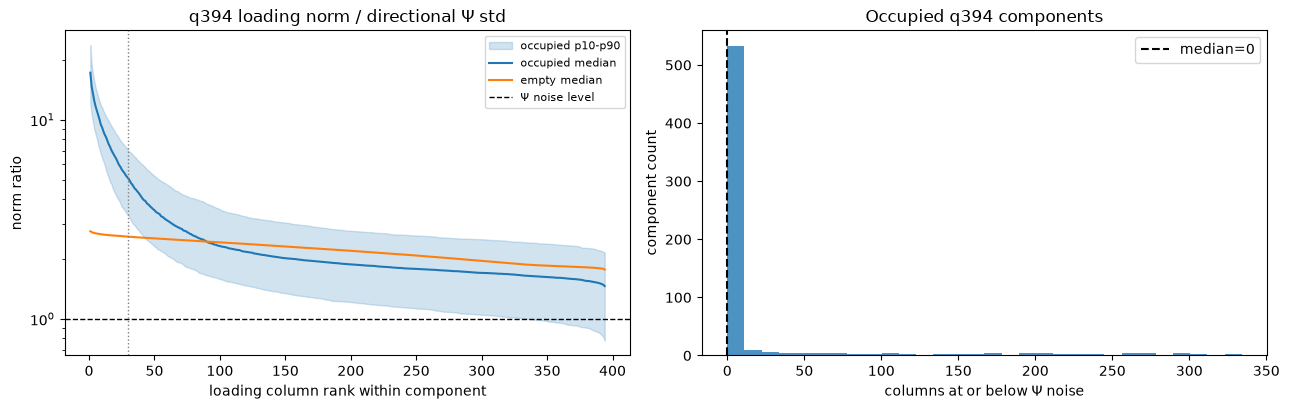

Occupied q394 components have a median of 0 and mean of 20.21 / 394 columns at or below directional Ψ noise.
Result: does not support the hypothesis that roughly 360 q394 columns sit at the likelihood noise floor.


In [11]:
if HAVE_BOTH_ASSIGNMENTS:
    q394_norm_to_noise = np.empty((K, q394_reader["q"]), dtype=np.float32)
    for shard in q394_reader["shards"]:
        state, meta = shard["state"], shard["meta"]
        component_start = int(meta["component_start"])
        local_K = int(meta["local_K"])
        eps = float(meta["eps_floor"])
        for batch_start in range(0, local_K, 8):
            batch_stop = min(batch_start + 8, local_K)
            direction = state["dir_raw"][batch_start:batch_stop].float()
            direction_norm_sq = direction.square().sum(dim=1).clamp_min(eps ** 2)
            directional_noise_variance = (
                direction.square() * q394_reader["psi"][None, :, None]
            ).sum(dim=1) / direction_norm_sq
            loading_norm = torch.nn.functional.softplus(
                state["scale_rho"][batch_start:batch_stop].float()
            )
            ratio = loading_norm / directional_noise_variance.sqrt()
            global_start = component_start + batch_start
            q394_norm_to_noise[global_start:global_start + ratio.shape[0]] = ratio.numpy()

    occupied_mask = col_counts > 0
    loading_noise_rows = []
    for group_name, group_mask in [
        ("all", np.ones(K, dtype=bool)),
        ("occupied", occupied_mask),
        ("empty", ~occupied_mask),
    ]:
        columns_above_noise = (q394_norm_to_noise[group_mask] > 1.0).sum(axis=1)
        columns_at_or_below_noise = q394_reader["q"] - columns_above_noise
        loading_noise_rows.append({
            "component_group": group_name,
            "components": int(group_mask.sum()),
            "mean_columns_above_noise": float(columns_above_noise.mean()),
            "median_columns_above_noise": float(np.median(columns_above_noise)),
            "mean_columns_at_or_below_noise": float(columns_at_or_below_noise.mean()),
            "median_columns_at_or_below_noise": float(np.median(columns_at_or_below_noise)),
            "p90_columns_at_or_below_noise": float(np.quantile(columns_at_or_below_noise, 0.9)),
        })
    loading_noise_summary = pd.DataFrame(loading_noise_rows)
    display(loading_noise_summary)

    occupied_ratios = np.sort(q394_norm_to_noise[occupied_mask], axis=1)[:, ::-1]
    empty_ratios = np.sort(q394_norm_to_noise[~occupied_mask], axis=1)[:, ::-1]
    occupied_below_noise = (q394_norm_to_noise[occupied_mask] <= 1.0).sum(axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
    column_ranks = np.arange(1, q394_reader["q"] + 1)
    occupied_median = np.median(occupied_ratios, axis=0)
    occupied_p10 = np.quantile(occupied_ratios, 0.1, axis=0)
    occupied_p90 = np.quantile(occupied_ratios, 0.9, axis=0)
    axes[0].fill_between(column_ranks, occupied_p10, occupied_p90, color="tab:blue", alpha=0.2, label="occupied p10-p90")
    axes[0].plot(column_ranks, occupied_median, color="tab:blue", label="occupied median")
    axes[0].plot(column_ranks, np.median(empty_ratios, axis=0), color="tab:orange", label="empty median")
    axes[0].axhline(1.0, color="black", linestyle="--", linewidth=1, label="Ψ noise level")
    axes[0].axvline(30, color="gray", linestyle=":", linewidth=1)
    axes[0].set(yscale="log", title="q394 loading norm / directional Ψ std", xlabel="loading column rank within component", ylabel="norm ratio")
    axes[0].legend(fontsize=8)

    axes[1].hist(occupied_below_noise, bins=30, color="tab:blue", alpha=0.8)
    axes[1].axvline(np.median(occupied_below_noise), color="black", linestyle="--", label=f"median={np.median(occupied_below_noise):.0f}")
    axes[1].set(title="Occupied q394 components", xlabel="columns at or below Ψ noise", ylabel="component count")
    axes[1].legend()
    fig.tight_layout()
    plt.show()

    median_below_noise = float(np.median(occupied_below_noise))
    mean_below_noise = float(occupied_below_noise.mean())
    print(
        f"Occupied q394 components have a median of {median_below_noise:.0f} and mean of "
        f"{mean_below_noise:.2f} / {q394_reader['q']} columns at or below directional Ψ noise."
    )
    if median_below_noise >= 300:
        print("Result: supports the hypothesis that most q394 columns sit at the likelihood noise floor.")
    else:
        print("Result: does not support the hypothesis that roughly 360 q394 columns sit at the likelihood noise floor.")
